<a href="https://colab.research.google.com/github/tbodtcher/Netflix-Analysis/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Netflix Titles: An Exploritory Data Analysis**

**Purpose**
The purpose of this exploritory data analysis (EDA) is to gain insights into this dataset, using my skills I have learned in Python. I will be attempting to discover common trends in genres, ratings, duration, and much more.

This data comes from a publicly avaliable dataset from *Kaggle*.

To begin, let's import the data and take a look at the first few rows to see how the data is formatted. We also can try to see if there will be any problems with duplicate or missing values.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,15-Aug-16,2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...
1,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,4-Apr-17,2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
2,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,16-Sep-16,2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
3,s108,Movie,A Champion Heart,David de Vos,"Mandy Grace, David de Vos, Donna Rusch, Devan ...",United States,4-Sep-21,2018,G,90 min,"Children & Family Movies, Dramas",When a grieving teen must work off her debt to...
4,s934,Movie,Hachi: A Dog's Tale,Lasse Hallström,"Richard Gere, Joan Allen, Cary-Hiroyuki Tagawa...","United Kingdom, United States",1-May-21,2009,G,93 min,"Children & Family Movies, Dramas","When his master dies, a loyal pooch named Hach..."


Looking at the first few rows of data, we can see that it is actually a very well formatted dataset. Data is clean, and clear to read. However, I want to check to make sure that we do not have any duplicate values, before I go into more detail.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8800 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [31]:
df.loc[ df.duplicated(subset=['title', 'show_id'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In the code above, I was able to indentify that there were no duplicate values. The code went through each row and tried to find rows that had the same "Show ID" and "Title". It found no rows, so I feel confident in saying that there are no duplicated values.

However, we can see that we do have some null values in our dataset, in various rows. Because we will be performing analysis functions on a variety of columns in this dataset, my decision will be to keep the rows will null values, but make note of them going forward. I believe the rest of the data in the rows are worth having.

Moving on to the actual analysis of our EDA, I want to start by looking at the summary statistics for our "Release Year" column. Movies have been made for a long time now, and I'm curious to see what the average release year and median release year are for this dataset. I know Netflix hasnt been around for long, but I know they have an impressive range of titles in their library.

My hypothesis is that the average release year will be in the mid-2000's (2005). I think this because of the large quantity of "Classic" movies that came out before then.

In [32]:
df['release_year'].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


After looking at the results of my code, I can see that the average release year for the titles in the dataset is 2014. While this is fairly close, my hypothesis is incorrect. The average year is a lot closer to today than I thought. This could be because of the high quantity of Netflix-made filmes and tv shows that Netflix is releasing.

Next, I want to see the most common ratings for both movies and tv shows. Again, I know that Netflix has a wide range of things to watch, so I am curious to see how the ratings are broken down for movies and TV shows.

In [33]:
movie = df.loc[df['type'] == 'Movie']
movie.value_counts(movie['rating'])

,count
rating,
TV-MA,2062
TV-14,1427
R,797
TV-PG,540
PG-13,490
PG,287
TV-Y7,139
TV-Y,131
TV-G,126


After viewing the results of my code, I was surprised to see that not all of the movie titles followed the traditional rating system. There were a lot of movies that had the TV-style ratings (TV-MA, TV-14, etc.). Upon further reasearch, I found that Netflix has started incorporating tv ratings with the goal of having more generic ratings across different countries that make films, along with standardizing ratings to help parents decide what their children can watch.

With that being said, the rating with the highest number of **movies** listed is TV-MA, with 2062 titles. For traditional movie ratings, R rated has the highest number of titles, with 797.

Now, let's look at TV shows.

In [37]:
tv = df.loc[df['type'] == 'TV Show']
tv.value_counts(tv['rating'])

,count
rating,
TV-MA,1145
TV-14,733
TV-PG,323
TV-Y7,195
TV-Y,176
TV-G,94
NR,5
R,2
TV-Y7-FV,1


TV shows follows movies, with TV-MA having the most titles at 1145. This result makes since as Netflix has been focusing a lot of their TV shows as documentary-style shows about serial killers and violent historical occurences.

Overall, I am a bit surprised at the amount of mature movies and tv shows that Netflix offers.

Continuing the thought process of high numbers of mature rated titles, let's look into the genres listed for each title, and try to find out which one is the most common. If I am right, the top genres should be associated with dramatic themes.

In [38]:
df['listed_in'] = df['listed_in'].str.split(',')

In [46]:
counts = {}
for i, row in df.iterrows():
  for x in row['listed_in']:
    x = x.strip( )
    if x in counts:
      counts[x] += 1
    else:
      counts[x] = 1

sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
print(sorted_counts)

[('International Movies', 2752), ('Dramas', 2427), ('Comedies', 1674), ('International TV Shows', 1351), ('Documentaries', 869), ('Action & Adventure', 859), ('TV Dramas', 763), ('Independent Movies', 756), ('Children & Family Movies', 641), ('Romantic Movies', 616), ('TV Comedies', 581), ('Thrillers', 577), ('Crime TV Shows', 470), ("Kids' TV", 451), ('Docuseries', 395), ('Music & Musicals', 375), ('Romantic TV Shows', 370), ('Horror Movies', 357), ('Stand-Up Comedy', 343), ('Reality TV', 255), ('British TV Shows', 253), ('Sci-Fi & Fantasy', 243), ('Sports Movies', 219), ('Anime Series', 176), ('Spanish-Language TV Shows', 174), ('TV Action & Adventure', 168), ('Korean TV Shows', 151), ('Classic Movies', 116), ('LGBTQ Movies', 102), ('TV Mysteries', 98), ('Science & Nature TV', 92), ('TV Sci-Fi & Fantasy', 84), ('TV Horror', 75), ('Cult Movies', 71), ('Anime Features', 71), ('Teen TV Shows', 69), ('Faith & Spirituality', 65), ('Movies', 57), ('TV Thrillers', 57), ('Stand-Up Comedy & T

Something to note is that this dataset does not list genres explicitly, they are categorized into the column "Listed In". This is in reference to the sections of the Netflix platform that people can look in to find titles that related to that topic.

The top 3 "Listed In" categories are "International Movies" - 2752 mentions, 'Dramas' - 2427 mentions, and 'Comedies' - 1674 movies.

Because we do not have direct genres, the international category has the most mentions. However, if we look for the first "Genre" category, it is Drama. This makes sense with the higher ratings, and confirms what I thought after our analysis of ratings.


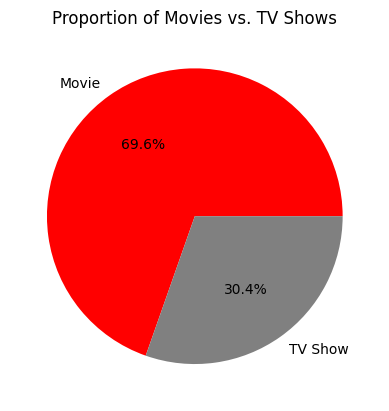

In [113]:
type_counts = df['type'].value_counts()

plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['red', 'grey'])
plt.title('Proportion of Movies vs. TV Shows')

plt.show()

Moving onto visualizations, I first made a pie chart that shows the breakdown of movies and tv shows as part of a whole. Out of our entire dataset, movies represent 69.6% of our data, while 30.4% of the data comes from TV Shows.

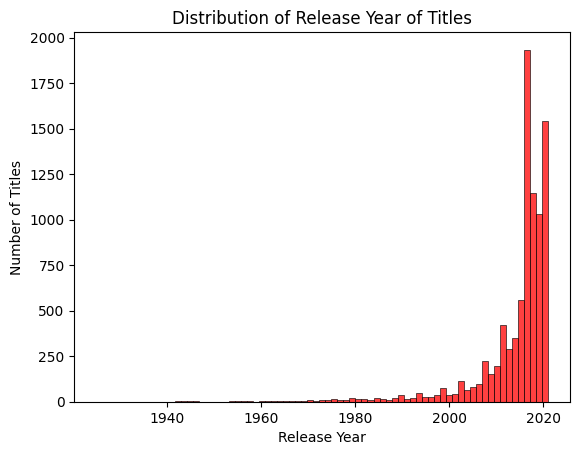

In [111]:
sns.histplot(x='release_year', data=df, bins=75, color='Red')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Distribution of Release Year of Titles')

plt.show()

This visualization is a histogram that shows the distribution of release year of the titles that we have from this dataset. As we can see, most of the titles that Netflix has on their platform were released after 2010. This explains why the average release year from earlier was so high!

In [108]:
top_countries = df['country'].value_counts().head(5)
top_countries

,count
country,
[United States],2818
[India],972
[United Kingdom],419
[Japan],245
[South Korea],199


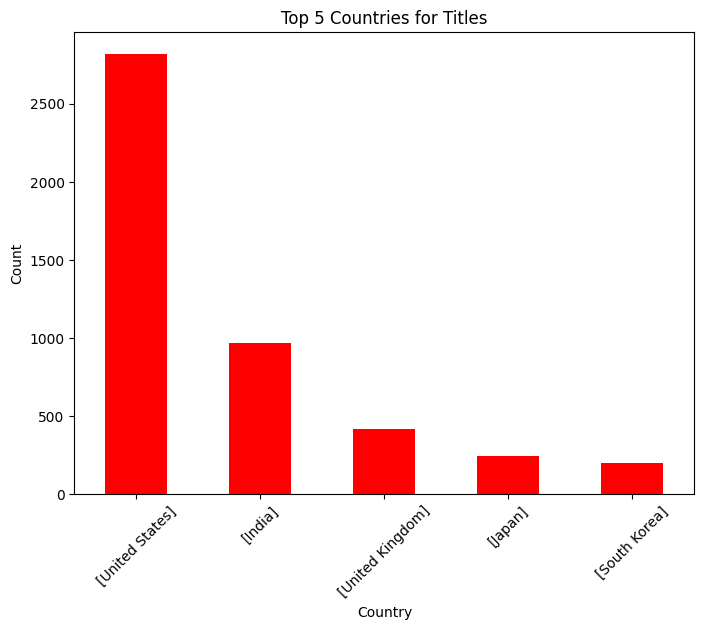

In [116]:
plt.figure(figsize=(8, 6))
top_countries.plot(kind='bar', color='red')
plt.title('Top 5 Countries for Titles')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Finally, this bar plot shows the top 5 countries with titles in Netflix. The United States has by far the most titles in this dataset, with over double the next highest country.

This does not surprise me since Netflix is Headquartered in the United States, so it makes sense that they would have the most amount of titles come from that company.

### *Conclusion*

After completing this EDA on the dataset of Netflix titles, I can say that I have a deeper understanding of the types of titles that Netflix carries, according to this dataset. Together, we learned that most of the titles that Netflix carries come from more modern times, and of those titles, most of them are maturely rated.

We looked at clear visualizations, and gained important insights into the data with pie charts, histograms, and bar plots.

Overall, this analysis has reaffirmed my knowledge that Netflix carries a vast library of titles, with different types of titles that would fit almost anyones needs for a relaxing streaming platform.